In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, euclidean_distances

from scipy.stats import mode

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive/Studia-II/Uczenie-Maszynowe/Lista7/Zad1

Liczba obrazów: 1797
Wymiar jednego obrazu: 64


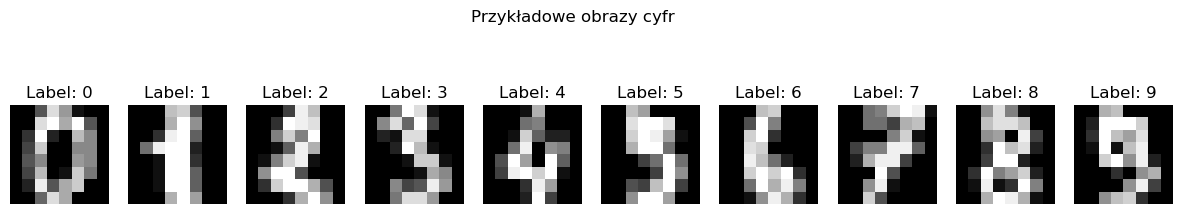

In [4]:
RANDOM_STATE = 2137

digits = load_digits()

X, y = digits.data, digits.target

print(f"Liczba obrazów: {X.shape[0]}")
print(f"Wymiar jednego obrazu: {X.shape[1]}")

fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i in range(10):
    axes[i].imshow(digits.images[i], cmap='gray')
    axes[i].set_title(f"Label: {y[i]}")
    axes[i].axis('off')
plt.suptitle("Przykładowe obrazy cyfr")
plt.show()

In [5]:
def experiment(X, y, labeled_fraction):
    """
    Eksperyment dla danego stosunku danych etykietowanych do całości
    """

    n_total = len(X)
    n_labeled = int(n_total * labeled_fraction)

    rng = np.random.RandomState(RANDOM_STATE)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    labeled_indices = indices[:n_labeled]
    unlabeled_indices = indices[n_labeled:]

    y_masked = np.full(n_total, -1)
    y_masked[labeled_indices] = y[labeled_indices]

    n_clusters = 10
    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
    cluster_lables = kmeans.fit_predict(X)
    cluster_centers = kmeans.cluster_centers_

    cluster_to_digit_map = {}
    clusters_with_lables = []
    clusters_without_lables = []

    for i in range(n_clusters):
        mask = (cluster_lables == i) & (y_masked != -1)
        known_lables_in_cluter = y_masked[mask]

        if len(known_lables_in_cluter) > 0:
            most_common = mode(known_lables_in_cluter, keepdims=True)[0][0] # samo mode zwraca coś takiego ModeResult(mode=[[3]], count=[[5]])
            cluster_to_digit_map[i] = most_common
            clusters_with_lables.append(i)
        else:
            clusters_without_lables.append(i)

    if clusters_without_lables:
        dists = euclidean_distances(cluster_centers)
        for i in clusters_without_lables:
            min_dist = np.inf
            nearest_labled = -1
            for j in clusters_with_lables:
                d = dists[i, j]
                if d < min_dist:
                    min_dist = d
                    nearest_labled = j

            cluster_to_digit_map[i] = cluster_to_digit_map[nearest_labled] if nearest_labled != -1 else 0 # nie powinno się wydarzyć, ale coś trzeba przypisać

    y_pred_clustering = np.array([cluster_to_digit_map[c] for c in cluster_lables])
    acc_clustering = accuracy_score(y[unlabeled_indices], y_pred_clustering[unlabeled_indices])

    n_neighbors = 5
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X[labeled_indices], y[labeled_indices])
    y_pred_knn = knn.predict(X[unlabeled_indices])
    acc_knn = accuracy_score(y[unlabeled_indices], y_pred_knn)

    return acc_clustering, acc_knn, len(clusters_without_lables)



In [6]:
from sklearn.model_selection import cross_val_score

full_clf_model = LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)

scores = cross_val_score(full_clf_model, X, y, cv=5)

FULL_SUPERVISED_ACC = scores.mean()

In [7]:
frac =[0.01, 0.05, 0.10, 0.20]

results = []

for f in frac:
    acc_c, acc_k, empty_clusters = experiment(X, y, f)

    results.append({
        "Etykiety (%)": f"{f*100:.0f}%",
        "Liczba etykietowanych danych": int(len(X) * f),
        "Puste klastry": empty_clusters,
        "Semi-Supervised (K-Means)": acc_c,
        "Supervised (k-NN)": acc_k,
        "100% Labels cross-val": FULL_SUPERVISED_ACC
    })

df_results = pd.DataFrame(results)
display_cols = ["Semi-Supervised (K-Means)", "Supervised (k-NN)", "100% Labels cross-val"]
df_display = df_results.style.format({col: "{:.2%}" for col in display_cols})

display(df_display)

,Etykiety (%),Liczba etykietowanych danych,Puste klastry,Semi-Supervised (K-Means),Supervised (k-NN),100% Labels cross-val
0,1%,17,1,68.54%,38.26%,91.49%
1,5%,89,0,78.40%,81.62%,91.49%
2,10%,179,0,78.37%,90.54%,91.49%
3,20%,359,0,78.30%,95.20%,91.49%
